# Homework 9 – Face Detection with dlib

## Step 0 – Import necessary libraries

In [2]:
import dlib
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

## Step 1 – Load an image

In [3]:
from google.colab import files
uploaded = files.upload()

Saving grup_0012_big.jpg to grup_0012_big (7).jpg


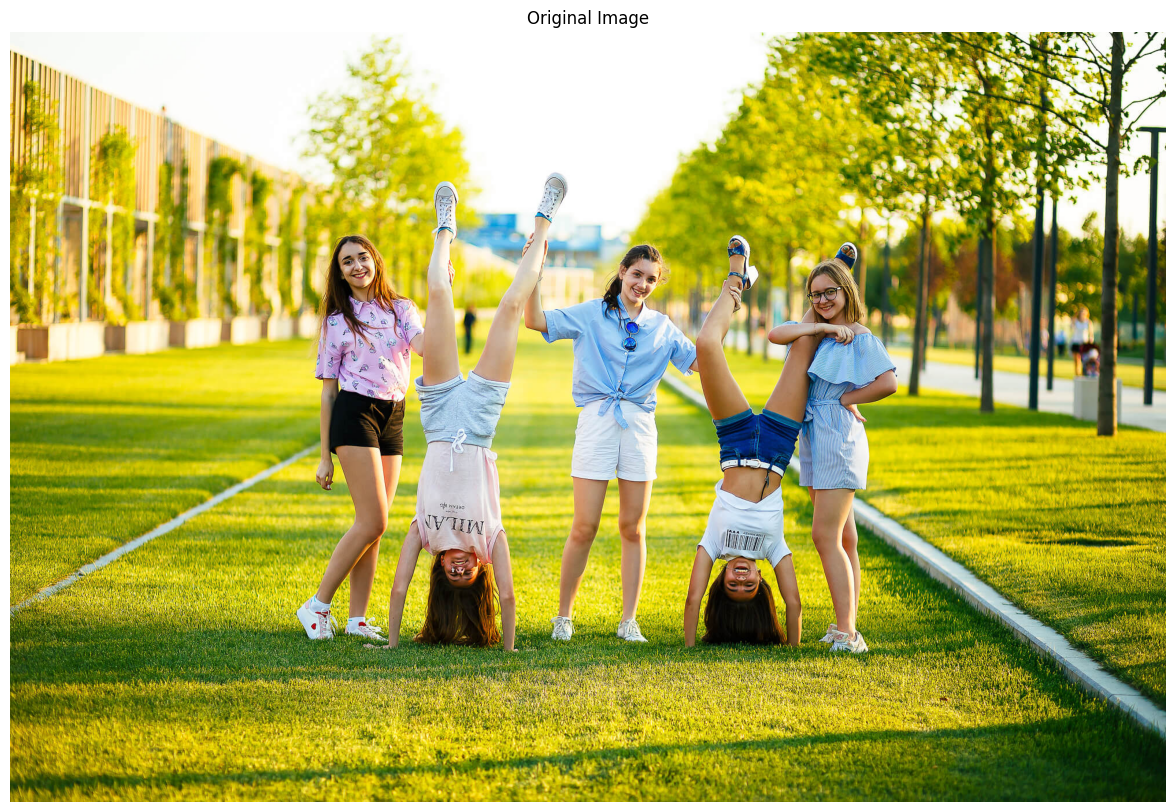

In [4]:
# Getting the file name
filename = list(uploaded.keys())[0]
img = cv2.imread(filename)

# Convert from BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.title('Original Image')
plt.show()

## Step 2 – Load dlib face detector
We use dlib’s default HOG-based frontal face detector.

In [5]:
# Initialize the HOG-based face detector
detector = dlib.get_frontal_face_detector()

## Step 3 – Run the detector on the image

In [6]:
# Detect faces (1 = upsample once to detect smaller faces)
rects = detector(img, 1)

print('Number of faces detected:', len(rects))
print(rects)
print(rects[0].left)

def rect_to_bb(rect):
  # Dlib rect --> OpenCV rect
    x = rect.left()
    y = rect.top()
    w = rect.right() - x
    h = rect.bottom() - y

    return (x, y, w, h)

Number of faces detected: 4
rectangles[[(570, 377) (633, 440)], [(1061, 405) (1123, 467)], [(1379, 433) (1441, 495)], [(1351, 382) (1394, 425)]]
<bound method PyCapsule.left of rectangle(570,377,633,440)>


## Step 4 – Draw bounding boxes around detected faces
Each face will have a different random color.

570 377 63 63
1061 405 62 62
1379 433 62 62
1351 382 43 43


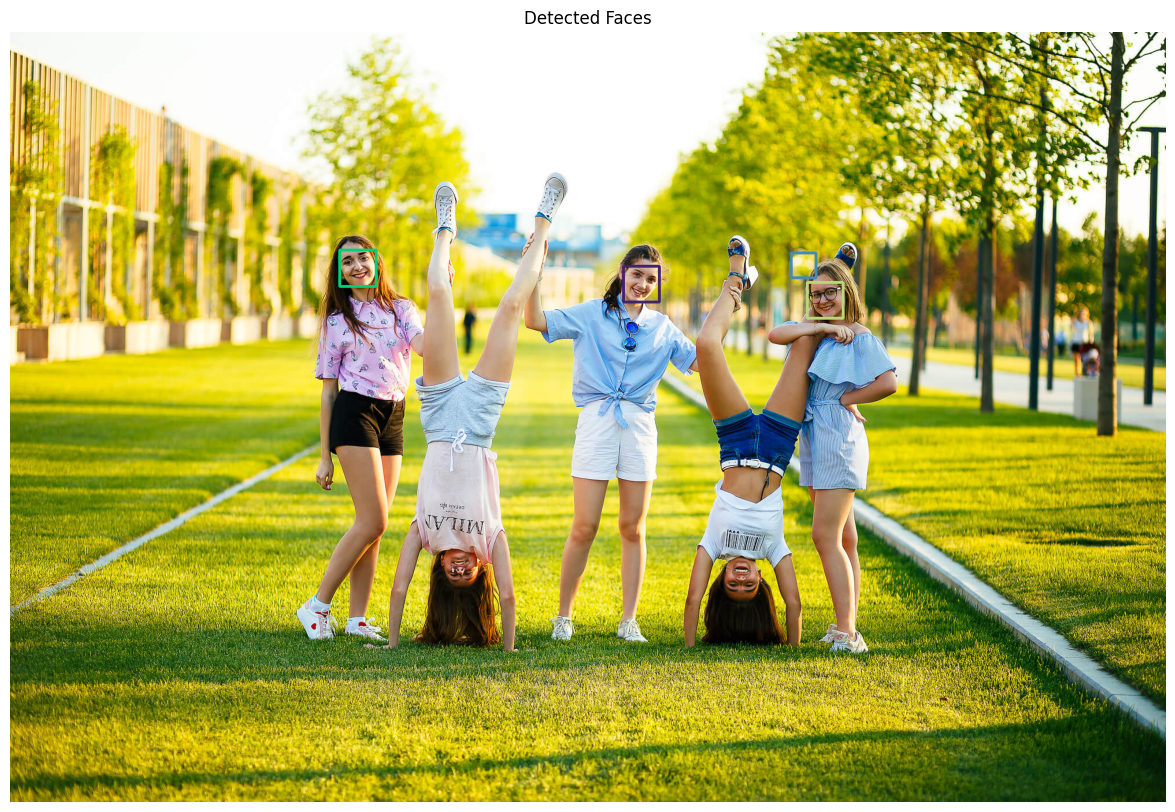

In [7]:
# Create a copy of the image to draw on
result_dlib = np.copy(img)
faces_dlib_img = []

# Generate random colors for each detected face
colors = [tuple(np.random.randint(0, 255, 3).tolist()) for _ in range(len(rects))]

# Draw rectangles
for i, rect in enumerate(rects):
    # Draw rectangle around the face
    x, y, w, h = rect_to_bb(rect)
    print(x, y, w, h)
    cv2.rectangle(result_dlib, (x, y), (x+w, y+h), colors[i], 3)
    faces_dlib_img.append(img[y:y+h, x:x+w, :])

# Show result
plt.imshow(result_dlib)
plt.axis('off')
plt.title('Detected Faces')
plt.show()

## Step 5 – Load dlib face detector
We use dlib’s default CNN-based frontal face detector.

In [8]:
# Download model
!wget http://dlib.net/files/mmod_human_face_detector.dat.bz2
!bunzip2 mmod_human_face_detector.dat.bz2

--2026-03-01 21:45:55--  http://dlib.net/files/mmod_human_face_detector.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/mmod_human_face_detector.dat.bz2 [following]
--2026-03-01 21:45:55--  https://dlib.net/files/mmod_human_face_detector.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 694709 (678K)
Saving to: ‘mmod_human_face_detector.dat.bz2.7’

mmod_human_face_det 100%[===================>] 678.43K  1.95MB/s    in 0.3s    

2026-03-01 21:45:56 (1.95 MB/s) - ‘mmod_human_face_detector.dat.bz2.7’ saved [694709/694709]

bunzip2: Output file mmod_human_face_detector.dat already exists.


Number of faces detected: 4
rectangles[[(570, 377) (633, 440)], [(1061, 405) (1123, 467)], [(1379, 433) (1441, 495)], [(1351, 382) (1394, 425)]]
<bound method PyCapsule.left of rectangle(570,377,633,440)>


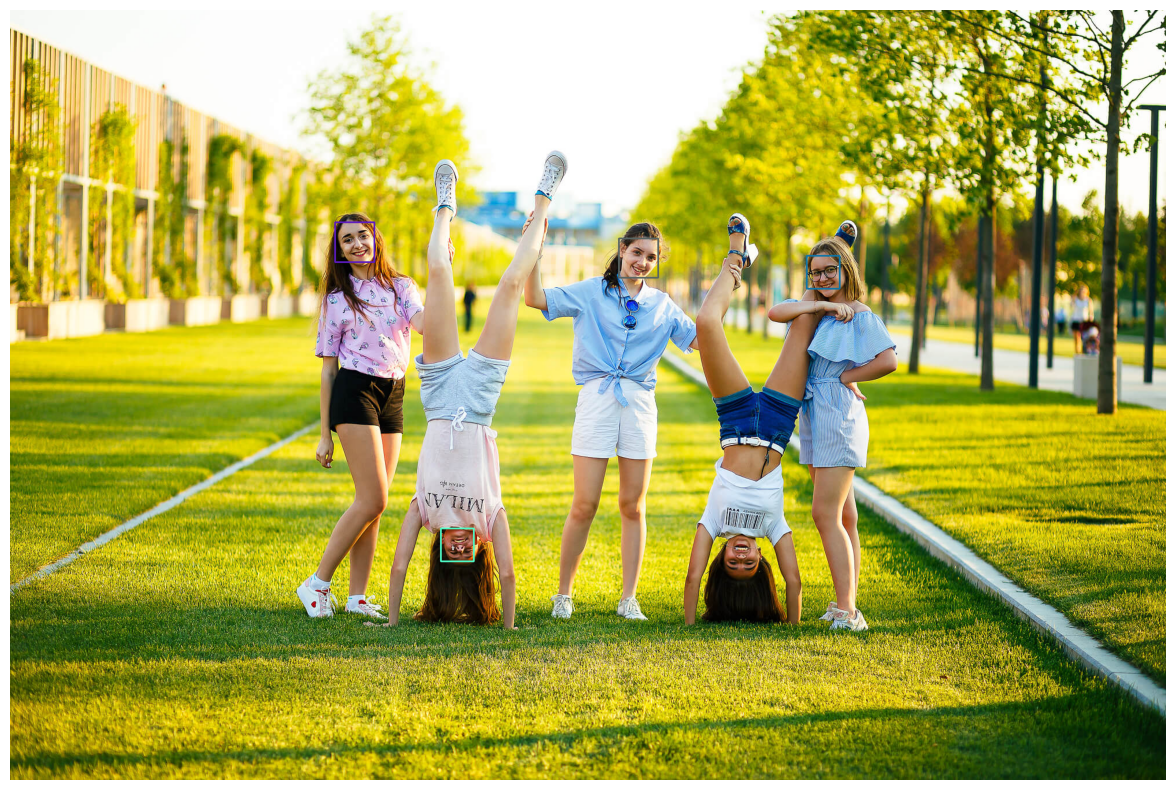

In [9]:
# Initialize the CNN-based face detector
cnn_detector = dlib.cnn_face_detection_model_v1("mmod_human_face_detector.dat")

detections = cnn_detector(img, 1)
print('Number of faces detected:', len(rects))
print(rects)
print(rects[0].left)

colors = [tuple(np.random.randint(0,255,3).tolist()) for _ in range(len(detections))]
img_copy = img.copy()

for i, det in enumerate(detections):
    x = det.rect.left()
    y = det.rect.top()
    w = det.rect.right()
    h = det.rect.bottom()
    cv2.rectangle(img_copy, (x, y), (w, h), colors[i], 2)

plt.imshow(img_copy)
plt.axis('off')
plt.show()

HOG detector показал низкую устойчивость к изменению ориентации лица и дал ложное срабатывание. CNN detector оказался более устойчивым и точным, не выдал false positives, однако также частично не справился с полностью перевёрнутыми лицами. В целом CNN демонстрирует более высокую надёжность при сложных условиях,но работает медленее.